# Work 2

## Imports

In [1]:
import pandas as pd
import os
from dotenv import load_dotenv
import pyarrow
from pathlib import Path
import boto3

In [2]:
load_dotenv()
os.getenv('AWS_ACCESS_KEY_ID') is not None

True

## Data set loading 

In [3]:
s3 = boto3.client('s3')

BUCKET = 'zrive-ds-data'
PREFIX = 'groceries/box_builder_dataset/'

response = s3.list_objects_v2(
    Bucket = BUCKET,
    Prefix = PREFIX
)

key = response['Contents'][0]['Key']
filename = response['Contents'][0]['Key'].split('/')[-1]

local_data_dir = Path('../../data/module2')
local_path = local_data_dir/filename

if local_path.exists():
        print(f'{filename} already exists')
else:
    print(f'Downloading: {filename}')
    s3.download_file(BUCKET,key,local_path)

Downloading: feature_frame.csv


In [5]:
df = pd.read_csv(local_path)
df.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


## EDA 1: Quick SAnity and integrity check

In [8]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nMissing values (%):\n", df.isna().mean()*100)
print("\nDuplicated rows:", df.duplicated().sum())

Shape: (2880549, 27)
Columns: ['variant_id', 'product_type', 'order_id', 'user_id', 'created_at', 'order_date', 'user_order_seq', 'outcome', 'ordered_before', 'abandoned_before', 'active_snoozed', 'set_as_regular', 'normalised_price', 'discount_pct', 'vendor', 'global_popularity', 'count_adults', 'count_children', 'count_babies', 'count_pets', 'people_ex_baby', 'days_since_purchase_variant_id', 'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id', 'days_since_purchase_product_type', 'avg_days_to_buy_product_type', 'std_days_to_buy_product_type']

Data types:
 variant_id                            int64
product_type                         object
order_id                              int64
user_id                               int64
created_at                           object
order_date                           object
user_order_seq                        int64
outcome                             float64
ordered_before                      float64
abandoned_before                

For now, the analysis shows that there is no columns with relatively strange percentages of na or duplicates. 
The datatypes are the ones expected for the columns except for created at and order date, which should be transformed into datetime. 
The shape fits the idea os a supermarket, a los of rows representign the pair (product,order) 
and several columns regarding the data.

In [15]:
date_cols = ['created_at','order_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col],errors = 'coerce')

df[date_cols].dtypes

created_at    datetime64[ns]
order_date    datetime64[ns]
dtype: object

## EDA 2: Data integrity

Each row represents an (order, product) pair, where the outcome variable indicates 
whether the product was purchased or not.

**Lets check the unique key**

In [10]:
df[['variant_id','order_id']].duplicated().sum()

0

In [11]:
df['outcome'].value_counts()

outcome
0.0    2847317
1.0      33232
Name: count, dtype: int64

No other values than 1 or 0, so that is correct.

In [14]:
df[['variant_id','order_id','outcome']].isna().sum()

variant_id    0
order_id      0
outcome       0
dtype: int64

The columnas that should always be filled, are indeed

## EDA 3: Univariant analysis

In [17]:
target_counts = df['outcome'].value_counts()
print(target_counts)

outcome
0.0    2847317
1.0      33232
Name: count, dtype: int64


In [18]:
target_ratio =  df['outcome'].value_counts(normalize = True)
print(target_ratio)

outcome
0.0    0.988463
1.0    0.011537
Name: proportion, dtype: float64


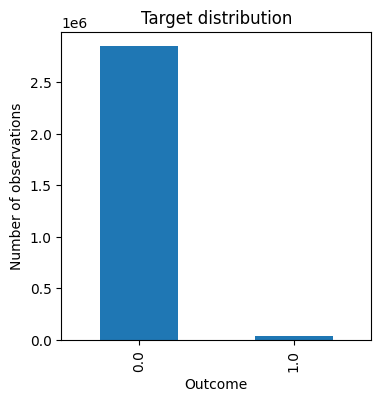

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
target_counts.plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Number of observations")
plt.title("Target distribution")
plt.show()

The target variable is imbalanced, with a higher proportion of non-purchased 
(product not bought) outcomes compared to purchased ones. This imbalance is 
expected in a supermarket context context and should be taken into account in downstream 
modeling and evaluation.

In [20]:
df.groupby("order_id")["outcome"].mean().describe()

count    3446.000000
mean        0.011713
std         0.008447
min         0.000000
25%         0.005663
50%         0.010518
75%         0.015964
max         0.089143
Name: outcome, dtype: float64

We can observe that from the products for each order, only 1.1% ends to be purchased.